In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


# Paths
PROJECT_ROOT = Path('../..').resolve()
PRICE_ADDERS = PROJECT_ROOT / '01_data' / '2_cleaned' / 'price_adders' / 'price_adders_hourly_20200101_20251204.csv'
OUT_DIR = PROJECT_ROOT / '01_data' / '3_analysis' / 'price_adders_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# import datasets

df_adders_numerical = pd.read_csv(PRICE_ADDERS)
df_adders_numerical = df_adders_numerical.rename(columns={'datetime': 'date'})
df_adders_numerical['date'] = pd.to_datetime(df_adders_numerical['date'])
df_adders_numerical = df_adders_numerical[df_adders_numerical['date'] < pd.to_datetime('2025-12-05')]
df_adders_numerical = df_adders_numerical[['date', 'RTRSVPOR', 'RTRSVPOFF', 'RTRDP']]
df_adders_numerical['adder_sum'] = df_adders_numerical['RTRSVPOR'] + df_adders_numerical['RTRSVPOFF'] + df_adders_numerical['RTRDP']
df_adders_numerical.to_csv(OUT_DIR / 'price_adders_numerical_analysis.csv', index=False)

In [3]:
# exclude 0 values
RTRSVPOR_values = df_adders_numerical[df_adders_numerical['RTRSVPOR'] != 0]['RTRSVPOR']
RTRSVPOFF_values = df_adders_numerical[df_adders_numerical['RTRSVPOFF'] != 0]['RTRSVPOFF']
RTRDP_values = df_adders_numerical[df_adders_numerical['RTRDP'] != 0]['RTRDP']
adder_sum_values = df_adders_numerical[df_adders_numerical['adder_sum'] != 0]['adder_sum']

print(f"RTRSVPOR: {len(RTRSVPOR_values)} non-zero values")
print(f"RTRSVPOFF: {len(RTRSVPOFF_values)} non-zero values")
print(f"RTRDP: {len(RTRDP_values)} non-zero values")
print(f"Adder Sum: {len(adder_sum_values)} non-zero values")

RTRSVPOR: 5168 non-zero values
RTRSVPOFF: 2627 non-zero values
RTRDP: 7082 non-zero values
Adder Sum: 10567 non-zero values


In [4]:
# set 0-1 values to 0 for better visualization
RTRSVPOR_values = pd.Series([0 if x < 1 else x for x in RTRSVPOR_values]).dropna()
RTRSVPOFF_values = pd.Series([0 if x < 1 else x for x in RTRSVPOFF_values]).dropna()
RTRDP_values = pd.Series([0 if x < 1 else x for x in RTRDP_values]).dropna()
adder_sum_values = pd.Series([0 if x < 1 else x for x in adder_sum_values]).dropna()

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_67227/1352252096.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


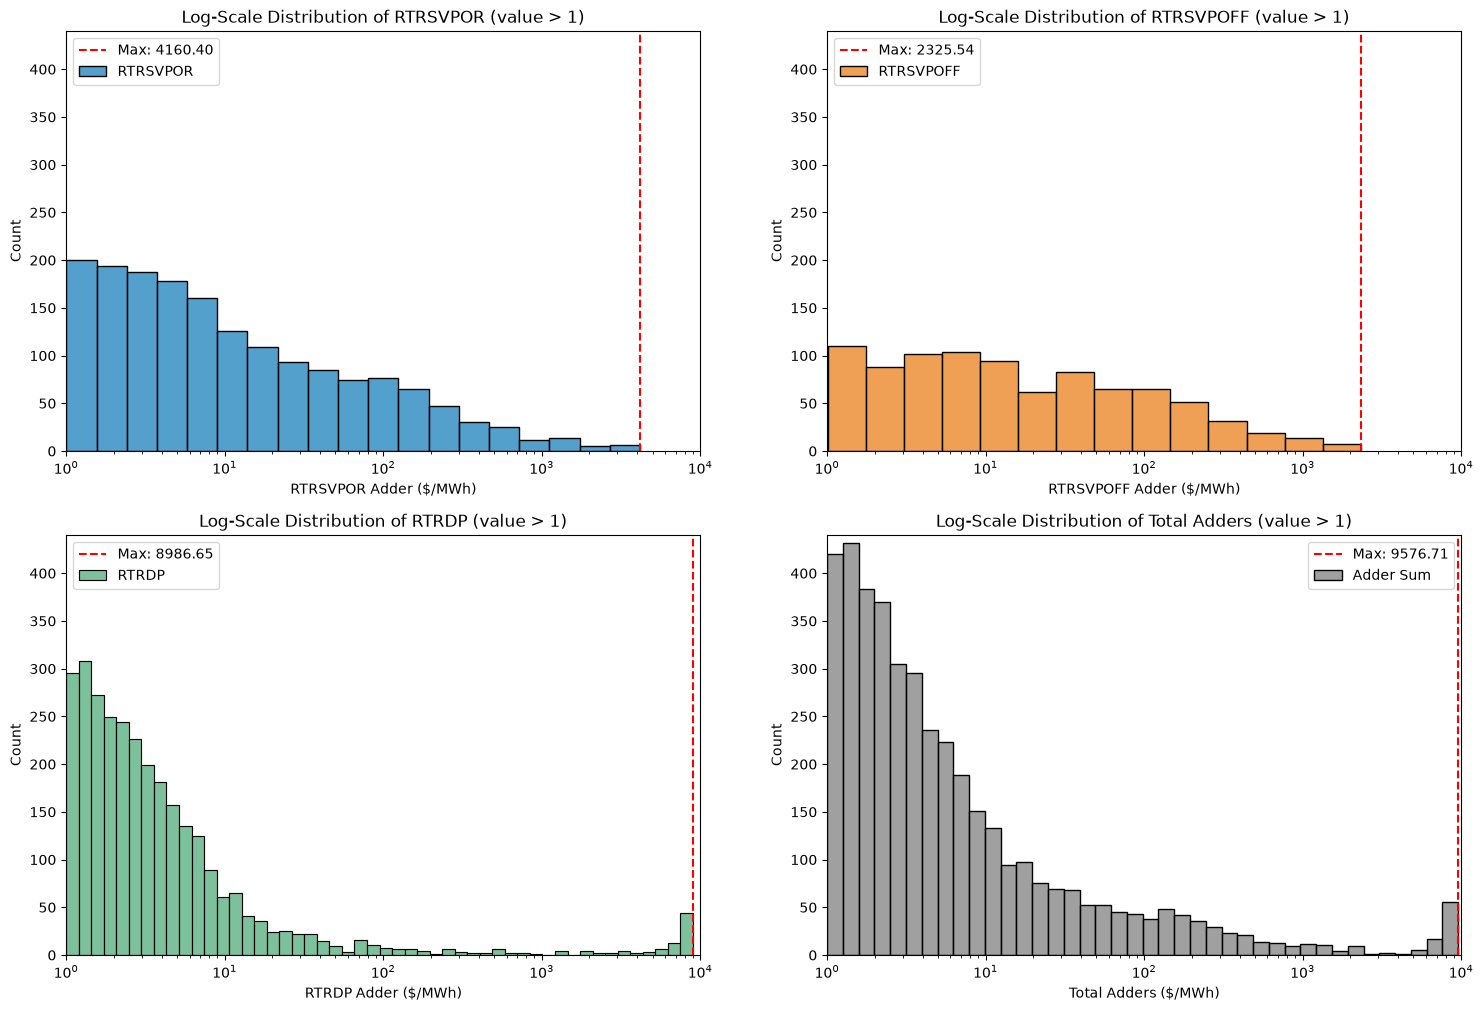

In [5]:
# pdf for price adders
fig, ax = plt.subplots(2, 2, figsize=(18, 12))
colors = ["#1a80bb", '#ea801c', "#50ad7b", "gray"]

sns.histplot(RTRSVPOR_values, label='RTRSVPOR', log_scale=True, color=colors[0], ax=ax[0, 0])
max_RTRSVPOR = max(RTRSVPOR_values) # add max value as vertical line
ax[0, 0].axvline(max_RTRSVPOR, color='red', linestyle='--', label=f'Max: {max_RTRSVPOR:.2f}')
ax[0, 0].legend()
ax[0, 0].set_xlim(1, 10000)
ax[0, 0].set_ylim(0, 440)
ax[0, 0].set_title('Log-Scale Distribution of RTRSVPOR (value > 1)')
ax[0, 0].set_xscale('log')
ax[0, 0].set_xlabel('RTRSVPOR Adder ($/MWh)')
ax[0, 0].set_ylabel('Count')
sns.histplot(RTRSVPOFF_values, label='RTRSVPOFF', log_scale=True, color=colors[1], ax=ax[0, 1])
max_RTRSVPOFF = max(RTRSVPOFF_values)
ax[0, 1].axvline(max_RTRSVPOFF, color='red', linestyle='--', label=f'Max: {max_RTRSVPOFF:.2f}')
ax[0, 1].legend()
ax[0, 1].set_xlim(1, 10000)
ax[0, 1].set_ylim(0, 440)
ax[0, 1].set_title('Log-Scale Distribution of RTRSVPOFF (value > 1)')
ax[0, 1].set_xscale('log')
ax[0, 1].set_xlabel('RTRSVPOFF Adder ($/MWh)')
ax[0, 1].set_ylabel('Count')
sns.histplot(RTRDP_values, label='RTRDP', log_scale=True, color=colors[2], ax=ax[1, 0])
max_RTRDP = max(RTRDP_values)
ax[1, 0].axvline(max_RTRDP, color='red', linestyle='--', label=f'Max: {max_RTRDP:.2f}')
ax[1, 0].legend()
ax[1, 0].set_xlim(1, 10000)
ax[1, 0].set_ylim(0, 440)
ax[1, 0].set_title('Log-Scale Distribution of RTRDP (value > 1)')
ax[1, 0].set_xscale('log')
ax[1, 0].set_xlabel('RTRDP Adder ($/MWh)')
ax[1, 0].set_ylabel('Count')
sns.histplot(adder_sum_values, label='Adder Sum', log_scale=True, color=colors[3], ax=ax[1, 1])
max_adder_sum = max(adder_sum_values)
ax[1, 1].axvline(max_adder_sum, color='red', linestyle='--', label=f'Max: {max_adder_sum:.2f}')
ax[1, 1].legend()
ax[1, 1].set_xlim(1, 10000)
ax[1, 1].set_ylim(0, 440)
ax[1, 1].set_title('Log-Scale Distribution of Total Adders (value > 1)')
ax[1, 1].set_xscale('log')
ax[1, 1].set_xlabel('Total Adders ($/MWh)')
ax[1, 1].set_ylabel('Count')

fig.savefig(OUT_DIR / 'price_adders_pdf.png', dpi=300)
fig.show()

In [6]:
# mean median std for price adders

print(f'RTRSVPOR values statistics:')
print(RTRSVPOR_values.describe())
print(f'\nRTRSVPOFF values statistics:')
print(RTRSVPOFF_values.describe())
print(f'\nRTRDP values statistics:')
print(RTRDP_values.describe())


RTRSVPOR values statistics:
count    5168.000000
mean       25.679643
std       163.622478
min         0.000000
25%         0.000000
50%         0.000000
75%         2.426250
max      4160.405000
dtype: float64

RTRSVPOFF values statistics:
count    2627.000000
mean       29.294098
std       136.170954
min         0.000000
25%         0.000000
50%         0.000000
75%         3.840000
max      2325.540000
dtype: float64

RTRDP values statistics:
count    7082.000000
mean       83.400929
std       772.295586
min         0.000000
25%         0.000000
50%         0.000000
75%         2.170000
max      8986.645000
dtype: float64


In [7]:
print(f'\nAdder sum values statistics:')
print(adder_sum_values.describe())


Adder sum values statistics:
count    10567.000000
mean        75.779044
std        699.138181
min          0.000000
25%          0.000000
50%          0.000000
75%          2.287500
max       9576.712500
dtype: float64
